<h1><b>TikTok Claims Classification Project </b></h1>

<h3>Capstone Project: Google Advanced Data Analytics Professional Certificate</h3>

<h2><b> Background and Business Problem</b></h2>
<p>TikTok’s user-generated content is vast, diverse, and growing rapidly. Users frequently report videos and comments that may contain factual claims or personal opinions. However, the manual moderation of these reports was time-consuming and inefficient — moderators were overwhelmed by the volume and struggled to prioritize content that required factual verification. This created a significant business challenge:
    
- Slower moderation response times
- Increased risk of misinformation spreading unchecked
- Higher operational costs due to manual sorting

To accelerate and optimize the content moderation process, TikTok aims to implement a predictive machine learning model that distinguishes between content that contains a verifiable claim and that which expresses a personal opinion. </p>

<h2><b>Business Impact</b></h2>
<p>Implementing a predictive model to classify user reported content into claims or opinions has direct and measurable business impact</p>
<ul>
    <li>Automating classifications will reduce repsonse time for high priority content.</li>
    <li>Moderators can focus only on claim-based content that may require verification saving time and cost </li>
    <li>Prioritizing actual claims ensures that the company stays ahead in mitigating misinformation and improves user trust</li>
</ul>

<h2><b>Methodology</b></h2>
<h4>1) Data Collection and Preparation </h4>
<ul>
    <li>The goal is to construct a dataframe in Python, perform initial inspection of the provided dataset, and inform TikTok data team members of the findings.</li>
    <li> Understanding the situation:How can the data be prepared and organized</li>
    <li> Understand the data: Creating necessary dataframes to understand the data and also to use in future for EDA and statistical analysis</li>
    <li>Understanding variables:  Using insights from the examination of the summary data to guide deeper investigation into variables</li>
    
</ul>


In [1]:
# Import packages
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import plotly.express as px
import seaborn as sns

In [2]:
data = pd.read_csv("tiktok_dataset.csv")

In [3]:
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


We can see that the data contains a mix of categorical, text and numerical data. Each row in the data represents the claim or opinion along with other metadata about the video. 

In [4]:
# get summary info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


There are a total of 19382 rows and 11 columns in the dataset with each column having datatype of either int64, object or float64. There are missing values in columns claim_status, video_transcription_text, video_view_count, video_like_count, video_share_count, video_download_count and video_comment_count.

In [5]:
# get summary statistics
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


Many count variables seems to have outliers at the high end of the distribution. The standard deviation and maximum values for some columns are very high as compared to the quartile values. Mean is significantly greater than median in some features indicating a right skewed distribution or presence of outliers on the higher end of the distribution. 

The variable of interest is claim_status as it tells us a bit more about the type of claim (claim or opinion) hence we will look more into it. 

In [6]:
data.claim_status.value_counts()

claim      9608
opinion    9476
Name: claim_status, dtype: int64

The count of each type of claim are balanced. 

Understanding each claim status as we our core objective is to create a machine learning model that classifies if a video contains a claim or opinion. 

Understanding the audience engagement with each claim type would be helpful as it will show which kind of videos have more view count

In [7]:
# Average view count of videos that are claims

claims = data[data.claim_status == 'claim']
print(f"Mean of claim status: {claims.video_view_count.mean()}")
print(f"Median of claim status: {claims.video_view_count.median()}")

Mean of claim status: 501029.4527477102
Median of claim status: 501555.0


In [8]:
# Average view count of videos that are opinions

opinions = data[data.claim_status == 'opinion']
print(f"Mean of opinion status: {opinions.video_view_count.mean()}")
print(f"Median of opinion status: {opinions.video_view_count.median()}")

Mean of opinion status: 4956.43224989447
Median of opinion status: 4953.0


The mean and median of each claim type are fairly similar however there is a vast difference in the mean and median of the view count between videos that are of claims and those that are opinion. Video views for videos that are considered claims are higher than those that are considered opinion. 

Understanding the author_ban feature with respect to claim status. This will allow us to understand how if there is any coorelation betweeen a certain claim status and author banned for having a video of such a status. 

In [9]:
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [10]:
data.groupby(['claim_status'])['author_ban_status'].value_counts()

claim_status  author_ban_status
claim         active               6566
              under review         1603
              banned               1439
opinion       active               8817
              under review          463
              banned                196
Name: author_ban_status, dtype: int64

There are more videos that are banned with claim status as compared to opinion status. This shows that videos with claims status might be more strictly moderated as compared to those that have opinions.  It is hard to say that the author is more likely to get banned because the video contained claim or if the author is more likely to violate rules and policies resulting in a ban. It also cannot be conluded that the video caused the ban even when the author obeyed the rules and policies.

Understanding more about the author ban status and the overall like, view and share for the videos. 

In [11]:
data.groupby(['author_ban_status']).agg({
    'video_view_count' : ['mean', 'median'], 
    'video_like_count' : ['mean', 'median'], 
    'video_share_count': ['mean', 'median']
})

video_view_count           video_like_count            \
                              mean    median             mean    median   
author_ban_status                                                         
active               215927.039524    8616.0     71036.533836    2222.0   
banned               445845.439144  448201.0    153017.236697  105573.0   
under review         392204.836399  365245.5    128718.050339   71204.5   

                  video_share_count           
                               mean   median  
author_ban_status                             
active                 14111.466164    437.0  
banned                 29998.942508  14468.0  
under review           25774.696999   9444.0

We can see that the mean and median view count of the videos with banned authors is extremely high as compared to that of the active authors. This needs to be investigated further. More viewers are vieweing, liking and sharing the videos with banned status. 

The mean for most groups is higher than the median indicating higher engagement on the such videos. 

In [12]:
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [13]:
data['like_per_view'] = data.video_like_count / data.video_view_count
data['share_per_view'] = data.video_share_count / data.video_view_count
data['comment_per_view'] = data.video_share_count / data.video_view_count

In [14]:
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,like_per_view,share_per_view,comment_per_view
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,0.056584,0.000702,0.000702
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,0.549096,0.135111,0.135111
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,0.108282,0.003168,0.003168
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,0.548459,0.079569,0.079569
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,0.622910,0.073175,0.073175


Understanding how the likes, share and comment differ for different author ban status and claim status 

In [15]:
data.groupby(['claim_status', 'author_ban_status']).agg({
    'like_per_view': ['count', 'mean','median'],
    'share_per_view' : ['count', 'mean','median'], 
    'comment_per_view': ['count', 'mean', 'median']
})

like_per_view                      \
                                       count      mean    median   
claim_status author_ban_status                                     
claim        active                     6566  0.329542  0.326538   
             banned                     1439  0.345071  0.358909   
             under review               1603  0.327997  0.320867   
opinion      active                     8817  0.219744  0.218330   
             banned                      196  0.206868  0.198483   
             under review                463  0.226394  0.228051   

                               share_per_view                      \
                                        count      mean    median   
claim_status author_ban_status                                      
claim        active                      6566  0.065456  0.049279   
             banned                      1439  0.067893  0.051606   
             under review                1603  0.065733  0.049967   
opinion      active                      8817  0.043729  0.032405   
             banned                       196  0.040531  0.030728   
             under review                 463  0.044472  0.035027   

                               comment_per_view                      
                                          count      mean    median  
claim_status author_ban_status                                       
claim        active                        6566  0.065456  0.049279  
             banned                        1439  0.067893  0.051606  
             under review                  1603  0.065733  0.049967  
opinion      active                        8817  0.043729  0.032405  
             banned                         196  0.040531  0.030728  
             under review                   463  0.044472  0.035027

We know from previous observations that the vidoes that had banned or under review get more user engagement in terms of likes, views and comments than those by active (non banned) users however when the vidoes are viewed the user engagement is less dependent on status of the author and more on the the claim status of the video. 


We know that the average view on claim videos are higher but the average likes are also higher on claim videos which shows that videos with claim status are highly regarded amongst audiences and also receive more engagement through comments and shares. 

Amongst the videos that are claims, banned authors have higher likes, shares and comments on average. On the other hand the videos that are opinion have higher average likes, shares and comments when the author is active/under review. 

<h4><b>2) EDA (Exploratory Data Analysis) </b></h4>
<ul>
    <li>The goal is to perform exploratory data analysis to understand the distribution of the data and clean the data. Find outliers and discuss how to handle them with the team. </li>
    <li> Selecting and building visualization for stakeholders to interact with</li>
    <li> Sharing results with team. </li>
    
</ul>

<p><b> video_duration_sec </b></p>

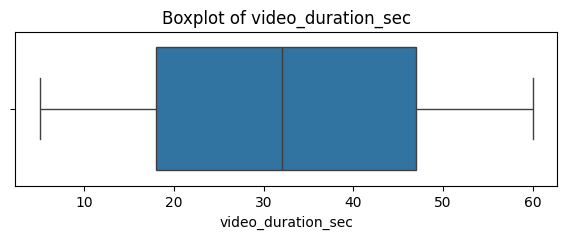

In [16]:
# boxplot 
df=data
plt.figure(figsize=(7,2))
plt.title("Boxplot of video_duration_sec")
sns.boxplot(x=df.video_duration_sec)
plt.show()

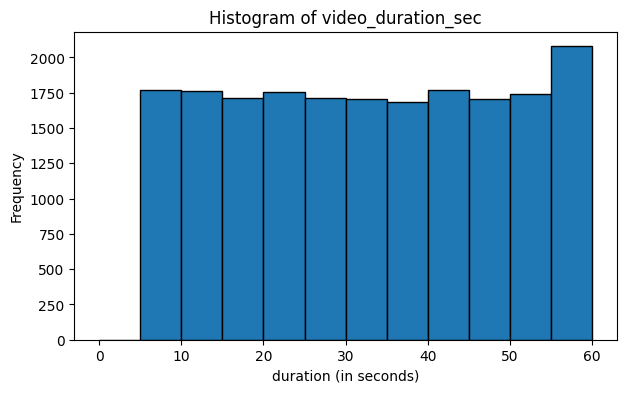

In [17]:
# histogram 
plt.figure(figsize=(7,4))
plt.title('Histogram of video_duration_sec')
plt.hist(df.video_duration_sec, bins=range(0,65,5), edgecolor='black')
plt.xlabel("duration (in seconds)")
plt.ylabel('Frequency')
plt.show()

The duration of the video is between 3 to 60 seconds and the distribution is uniform. 

<p><b>video_view_count</b></p>

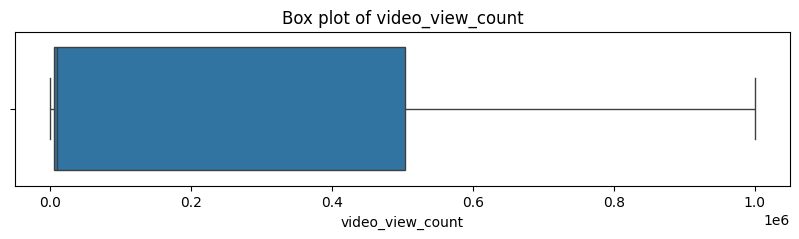

In [18]:
# boxplot
plt.figure(figsize=(10,2))
plt.title("Box plot of video_view_count")
sns.boxplot(data=df, x='video_view_count')
plt.show()

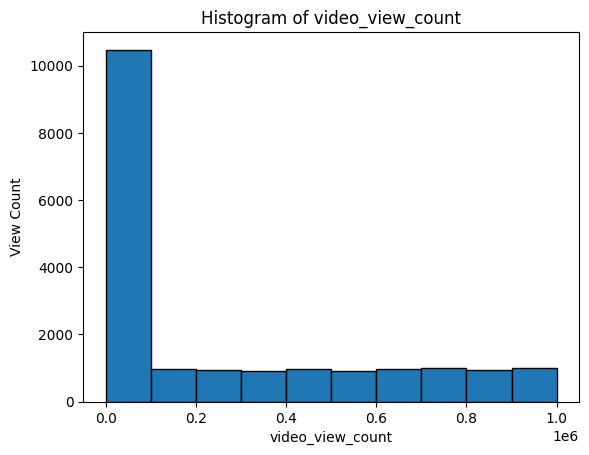

In [19]:
# histogram
plt.title("Histogram of video_view_count")
plt.hist(x=df.video_view_count, edgecolor='black', bins=range(0, 10**6+1, 10**5))
plt.xlabel("video_view_count")
plt.ylabel('View Count')
plt.show()

The data is skewed to the left as there are many videos where the view count is below 100000. The distribution after 100000 views is uniform. 

<p><b>video_like_count</b></p>

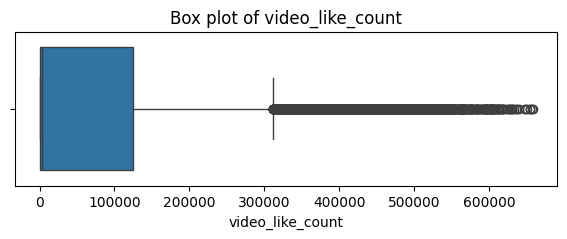

In [20]:
# bxoplot 
plt.figure(figsize=(7,2))
plt.title('Box plot of video_like_count')
sns.boxplot(x=df.video_like_count)
plt.show()

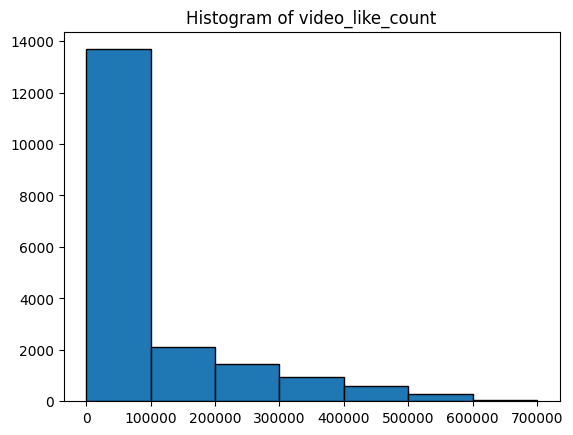

In [21]:
plt.title("Histogram of video_like_count" )
plt.hist(x=df.video_like_count, edgecolor='black', bins=range(0, 7*10**5+1, 10**5))
plt.show()

There are many videos with less than 100000 view counts. However, there is taper, data skews to the right indicating many videos on the upper extremety of like counts and contains outliers. 

<p><b>video_comment_count</b></p>

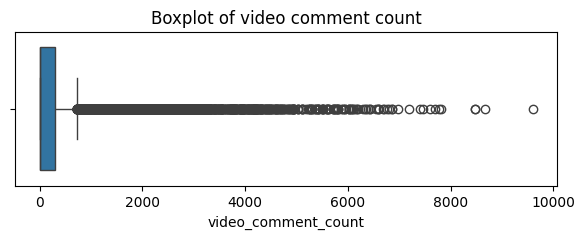

In [22]:
# boxplot 
plt.figure(figsize=(7,2))
plt.title("Boxplot of video comment count")
sns.boxplot(data=df, x='video_comment_count')
plt.show()

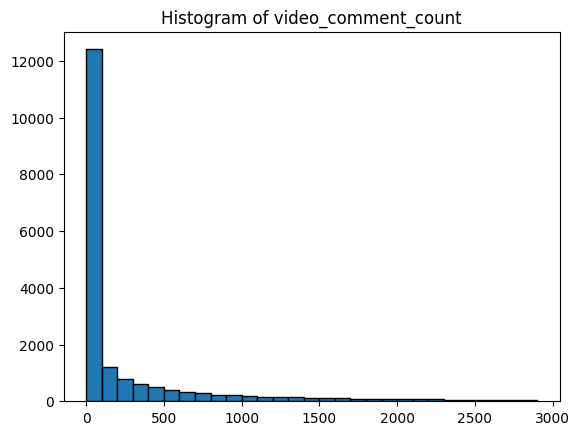

In [23]:
plt.title("Histogram of video_comment_count")
plt.hist(x=df.video_comment_count , edgecolor='black', bins=range(0, 3000, 100))
plt.show()

Like before the majority of the comments on videos are on the lower end of the range of video comment count. Most of the videos have less than 100 comments and the data is right skewed and contains outliers. 

<p><b>video_share_count</b></p>

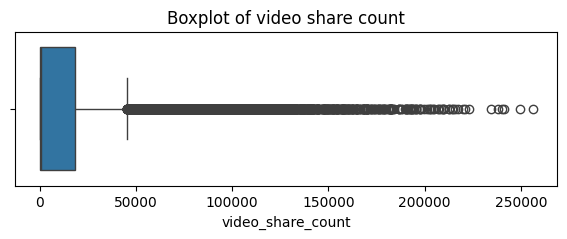

In [24]:
plt.figure(figsize=(7,2))
plt.title("Boxplot of video share count")
sns.boxplot(data=df, x='video_share_count')
plt.show()

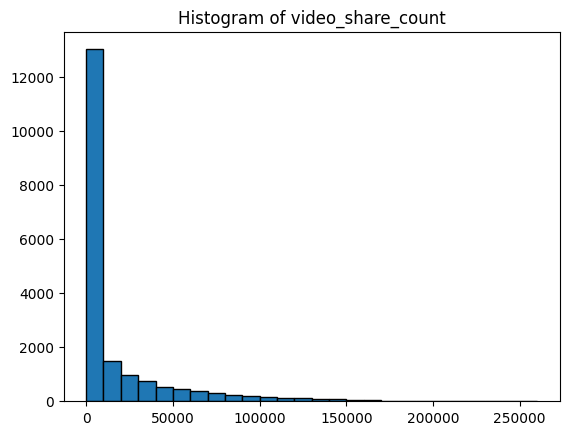

In [25]:
plt.title("Histogram of video_share_count")
plt.hist(x=df.video_share_count , edgecolor='black', bins=range(0, 270000, 10000))
plt.show()

Majority of videos have less than 10000 shares. The data is highly right skewed and contains outliers. 

<p><b>video_download_count</b></p>

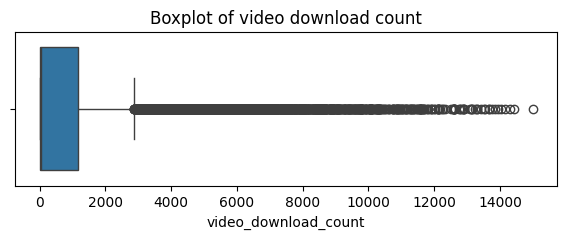

In [26]:
plt.figure(figsize=(7,2))
plt.title("Boxplot of video download count")
sns.boxplot(data=df, x='video_download_count')
plt.show()

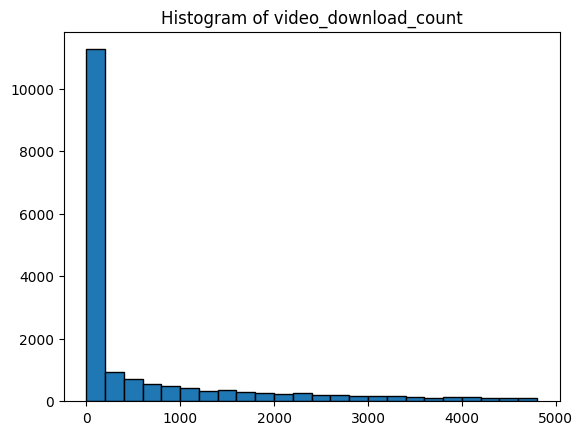

In [27]:
plt.title("Histogram of video_download_count")
plt.hist(x=df.video_download_count , edgecolor='black', bins=range(0, 5000, 200))
plt.show()

Most videos were downloaded less than 200 times and the data the highly right skewed and contains outliers.  

<p><b> Claim status by verification status </b></p>

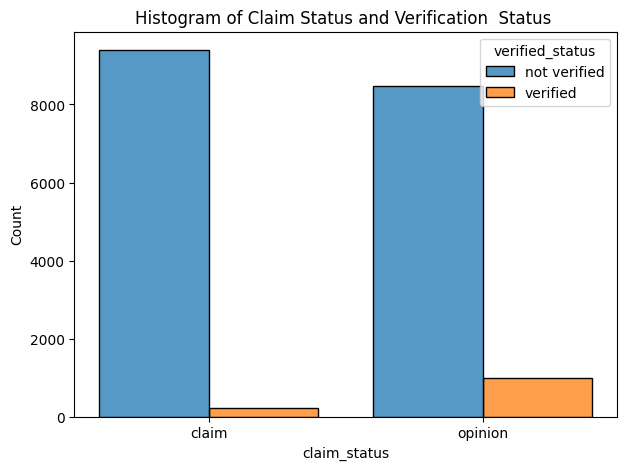

In [28]:
plt.figure(figsize=(7,5))
sns.histplot(data =df, 
            x='claim_status', 
            hue='verified_status', 
            multiple='dodge',
            shrink=0.8)

plt.title("Histogram of Claim Status and Verification  Status ")
plt.show()

There is a large number of videos where the user is not verified in both status. Among those that are verified, the videos tend to be opinions than claims.  

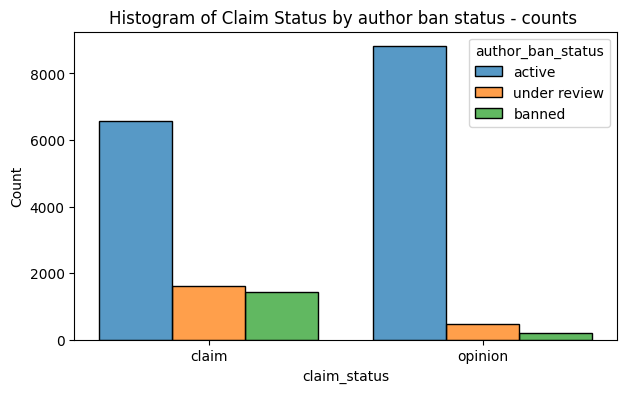

In [29]:
plt.figure(figsize=(7,4))
sns.histplot(data =df, 
            x='claim_status', 
            hue='author_ban_status', 
            multiple='dodge',
             hue_order=['active', 'under review', 'banned'],
            shrink=0.8)

plt.title("Histogram of Claim Status by author ban status - counts ")
plt.show()

In both claims and opinion, active authors are more than the banned or under review ones. Opinion vidoes have higher active authors than claims. However, claim video have higher number of under review or banned authors than videos that have claims. This shows that the authors who post claims tend to get banned or come under review. 

<p><b>Median view counts by ban status</b></p>

In [82]:
# average ban status
ban_status = df.groupby(['author_ban_status']).median(numeric_only=True).reset_index()
ban_status

,author_ban_status,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,like_per_view,share_per_view,comment_per_view
0,active,10966.0,5.624036e+09,33.0,8616.0,2222.0,437.0,28.0,5.0,0.254227,0.038429,0.038429
1,banned,5304.0,5.563176e+09,32.0,448201.0,105573.0,14468.0,892.0,209.0,0.325045,0.048507,0.048507
2,under review,6175.5,5.607722e+09,31.0,365245.5,71204.5,9444.0,610.5,136.5,0.290504,0.045357,0.045357


<Figure size 200x500 with 0 Axes>

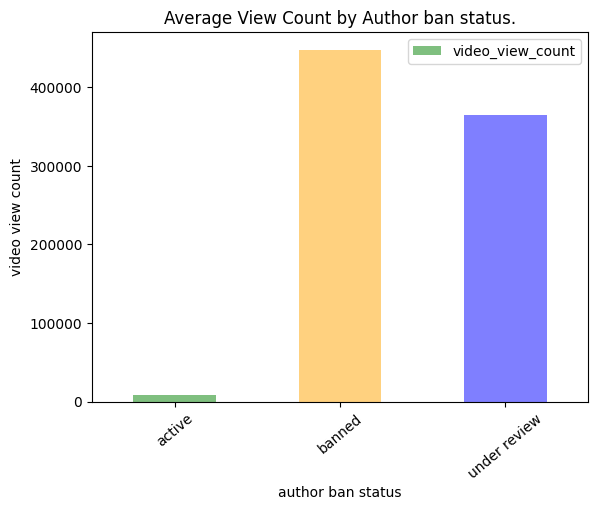

In [88]:
# visualization 
plt.figure(figsize = (2,5))
ban_status.plot(
    kind='bar', 
    x = 'author_ban_status', 
    y = 'video_view_count',
    color = ['green', 'orange', 'blue'],
    alpha=0.5,
    xlabel= 'author ban status', 
    ylabel='video view count',
    rot=40,
)

plt.title('Average View Count by Author ban status.')
plt.show()

The average view count for non active authors is far larger than that of active authors. From previous results we also know that the non active authors are far more likely to post claims than opinions ad also get higher views on average than that of active authors. This shows that video_view_count is a good indicator of claim status. 

In [89]:
# median view count for claim status
df.groupby(['claim_status']).agg({'video_view_count':'median'})

,video_view_count
claim_status,
claim,501555.0
opinion,4953.0


<p><b>Total view by claim status</b></p>

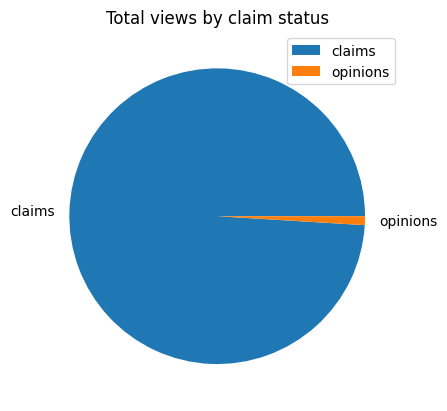

In [105]:
data = df.groupby(['claim_status']).agg({'video_view_count':'sum'}).reset_index()
data
data.plot(
    kind='pie', 
    x = 'claim_status', 
    y = 'video_view_count', 
    ylabel=' ', 
    labels=['claims', 'opinions'],
    
)

plt.title('Total views by claim status')
plt.show()

The overall view count is dominated by the claims as compared to opinions even though claims and opinions have the same amount of videos each. 

<p><b>Determing and handling outliers</b></p>

In normal distibution outliers can be found by setting the threshold to 1.5 * iqr above  upper bound and and 1.5 * iqr below lower bound, however, in this case TikTok count data is not a normal distibution and is highly skewed to the right. In this case we will modify the outlier threshold by taking median and then adding 1.5*iqr to it. This lowers the threshold as compared to what it would be if we used the third quartile still capturing a few outliers, which we do not want.

In [108]:
col_names = ['video_view_count','video_like_count','video_share_count','video_download_count','video_comment_count']

for col in col_names:
    #1QR
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1

    # bounds
    median = df[col].median()
    upper_bound = median + ((1.5)*iqr)
    outlier_count = (df[col] > upper_bound).sum()

    print(f"Number of outliers in column {col}: {outlier_count}")
        
        
        

Number of outliers in column video_view_count: 2343
Number of outliers in column video_like_count: 3468
Number of outliers in column video_share_count: 3732
Number of outliers in column video_download_count: 3733
Number of outliers in column video_comment_count: 3882


<p><b>Scatterplots</b></p>

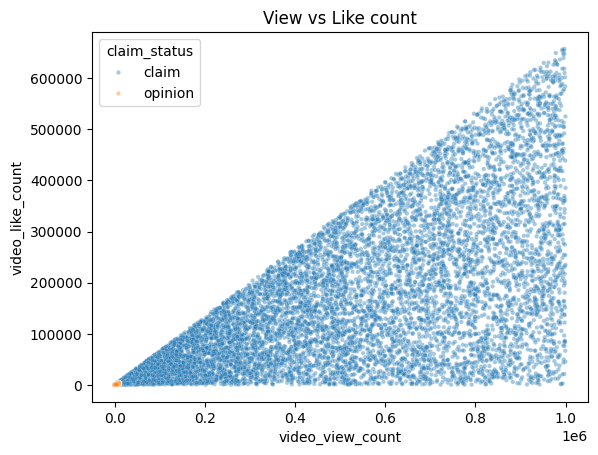

In [115]:
# Undestanding a bit more on 
sns.scatterplot(data=df, x='video_view_count', y='video_like_count', hue='claim_status', s=10, alpha=0.4)
plt.title("View vs Like count")
plt.show()

Text(0.5, 1.0, 'View vs Like count (for Claim status - opinion)')

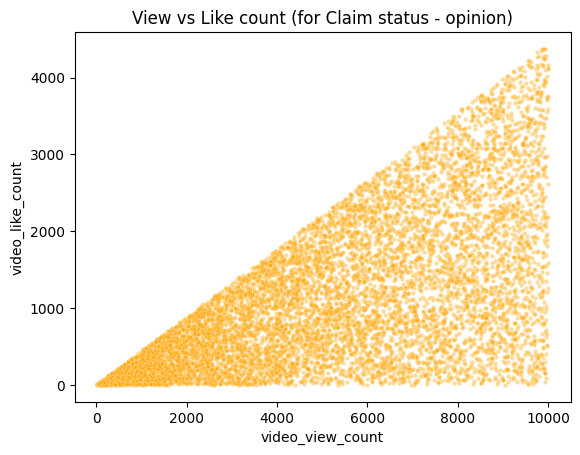

In [122]:
# Understanding a bit more about opinion statusabs

data = df[df.claim_status == 'opinion']

sns.scatterplot(data = data, x='video_view_count', y='video_like_count', s=10, alpha=0.4, color='orange' )
plt.title("View vs Like count (for Claim status - opinion)")